# 03 - Training and Evaluation (NASA C-MAPSS)

This notebook covers Phase 3 of the implementation plan:
- Train a RandomForest baseline on rolling window features
- Train a PyTorch LSTM on sequence windows
- Compare RMSE, MAE, and NASA score on a unit-wise validation split
- Log metrics and artifacts with MLflow

## Colab setup

If running in Google Colab, install dependencies before executing cells.

Example:
```bash
pip install -r requirements.txt
```

In [1]:
from pathlib import Path
import sys


def find_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "src").exists() and (candidate / "data").exists():
            return candidate
    raise FileNotFoundError("Could not locate project root containing src/ and data/.")


PROJECT_ROOT = find_project_root(Path.cwd().resolve())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

PROJECT_ROOT

PosixPath('/Users/ayushkanyal/Desktop/Predictive Maintainence')

In [2]:
import mlflow
import mlflow.pytorch
import mlflow.sklearn
import numpy as np
import pandas as pd
import torch

from src.models import split_by_unit, train_lstm_regressor, train_random_forest_baseline

pd.set_option("display.max_columns", 140)

/Users/ayushkanyal/Desktop/Predictive Maintainence/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
ROLLING_PATH = PROCESSED_DIR / "train_FD001_rolling_features.parquet"
SEQUENCE_LENGTH = 30
SEQUENCE_X_PATH = PROCESSED_DIR / f"train_FD001_sequences_x_t{SEQUENCE_LENGTH}.npy"
SEQUENCE_Y_PATH = PROCESSED_DIR / f"train_FD001_sequences_y_t{SEQUENCE_LENGTH}.npy"
SEQUENCE_INDEX_PATH = PROCESSED_DIR / f"train_FD001_sequence_index_t{SEQUENCE_LENGTH}.parquet"

for path in [ROLLING_PATH, SEQUENCE_X_PATH, SEQUENCE_Y_PATH, SEQUENCE_INDEX_PATH]:
    if not path.exists():
        raise FileNotFoundError(f"Missing artifact: {path}. Run notebook 02 first.")

rolling_df = pd.read_parquet(ROLLING_PATH)
x_seq = np.load(SEQUENCE_X_PATH)
y_seq = np.load(SEQUENCE_Y_PATH)
seq_index = pd.read_parquet(SEQUENCE_INDEX_PATH)

print("Rolling shape:", rolling_df.shape)
print("Sequence X shape:", x_seq.shape)
print("Sequence y shape:", y_seq.shape)
print("Sequence index shape:", seq_index.shape)

Rolling shape: (20131, 140)
Sequence X shape: (17731, 30, 17)
Sequence y shape: (17731,)
Sequence index shape: (17731, 3)


In [4]:
if len(seq_index) != len(x_seq) or len(seq_index) != len(y_seq):
    raise ValueError("Sequence arrays and sequence index must have identical sample counts.")

safe_mode = True
validation_fraction = 0.2
random_state = 42
max_cpu_threads = 2 if safe_mode else 0

rf_n_estimators = 250 if safe_mode else 500
rf_n_jobs = max_cpu_threads if max_cpu_threads > 0 else -1

lstm_hidden_size = 128
lstm_num_layers = 2
lstm_dropout = 0.2
lstm_learning_rate = 1e-3
lstm_batch_size = 128 if safe_mode else 256
lstm_epochs = 8 if safe_mode else 20
lstm_patience = 3 if safe_mode else 4
lstm_device = "cpu"

if max_cpu_threads > 0:
    torch.set_num_threads(max_cpu_threads)

metadata_cols = {"unit_id", "cycle", "rul", "rul_raw"}
rolling_feature_cols = [col for col in rolling_df.columns if col not in metadata_cols]

train_roll_df, validation_roll_df, validation_units = split_by_unit(
    rolling_df,
    validation_fraction=validation_fraction,
    random_state=random_state,
)

validation_mask = seq_index["unit_id"].isin(set(validation_units)).to_numpy()
x_seq_train = x_seq[~validation_mask]
y_seq_train = y_seq[~validation_mask]
x_seq_validation = x_seq[validation_mask]
y_seq_validation = y_seq[validation_mask]

print("Safe mode:", safe_mode)
print("Max CPU threads:", max_cpu_threads if max_cpu_threads > 0 else "default")
print("Rolling feature count:", len(rolling_feature_cols))
print("Validation units:", validation_units.tolist())
print("Rolling train/validation rows:", len(train_roll_df), len(validation_roll_df))
print("Sequence train/validation samples:", len(x_seq_train), len(x_seq_validation))

Safe mode: True
Max CPU threads: 2
Rolling feature count: 136
Validation units: [3, 5, 19, 22, 25, 26, 28, 34, 43, 51, 52, 53, 57, 60, 62, 72, 82, 93, 98, 100]
Rolling train/validation rows: 16379 3752
Sequence train/validation samples: 14459 3272


In [5]:
baseline_result = train_random_forest_baseline(
    train_df=train_roll_df,
    validation_df=validation_roll_df,
    feature_columns=rolling_feature_cols,
    target_col="rul",
    random_state=random_state,
    n_estimators=rf_n_estimators,
    max_depth=None,
    n_jobs=rf_n_jobs,
)

baseline_metrics = baseline_result.validation_metrics
print("Baseline validation metrics:")
for key, value in baseline_metrics.items():
    print(f"  {key}: {value:.4f}")

Baseline validation metrics:
  rmse: 16.6912
  mae: 11.7403
  nasa_score: 33798.2982


In [6]:
lstm_result = train_lstm_regressor(
    x_train=x_seq_train,
    y_train=y_seq_train,
    x_validation=x_seq_validation,
    y_validation=y_seq_validation,
    hidden_size=lstm_hidden_size,
    num_layers=lstm_num_layers,
    dropout=lstm_dropout,
    learning_rate=lstm_learning_rate,
    batch_size=lstm_batch_size,
    epochs=lstm_epochs,
    patience=lstm_patience,
    random_state=random_state,
    device=lstm_device,
)

lstm_metrics = lstm_result.best_validation_metrics
print("LSTM device:", lstm_device)
print("LSTM best epoch:", lstm_result.best_epoch)
print("LSTM validation metrics at best epoch:")
for key, value in lstm_metrics.items():
    print(f"  {key}: {value:.4f}")

lstm_result.history.tail()

LSTM device: cpu
LSTM best epoch: 8
LSTM validation metrics at best epoch:
  rmse: 41.4496
  mae: 36.5466
  nasa_score: 591225.3451
  loss: 1718.0698


,epoch,train_loss,train_rmse,validation_loss,validation_rmse,validation_mae,validation_nasa_score
3,4.0,1807.317957,42.512562,1727.725819,41.565921,36.514189,691591.300819
4,5.0,1808.048077,42.521149,1720.613744,41.480281,36.532379,622423.081410
5,6.0,1816.326123,42.618378,1735.924372,41.664426,36.511468,758026.023359
6,7.0,1815.439690,42.607977,1719.091870,41.461932,36.539477,604497.091517
7,8.0,1815.718042,42.611243,1718.069827,41.449606,36.546579,591225.345100


In [7]:
comparison_df = pd.DataFrame(
    [
        {"model": "random_forest", **baseline_metrics},
        {"model": "lstm", **lstm_metrics},
    ]
)

tracking_dir = PROJECT_ROOT / "mlruns"
tracking_dir.mkdir(parents=True, exist_ok=True)
mlflow.set_tracking_uri(tracking_dir.as_uri())
mlflow.set_experiment("cmapss_phase3_modeling")

run_name = f"FD001_phase3_rf_vs_lstm_safe_{int(safe_mode)}"
with mlflow.start_run(run_name=run_name) as run:
    mlflow.log_param("dataset_id", "FD001")
    mlflow.log_param("safe_mode", int(safe_mode))
    mlflow.log_param("max_cpu_threads", max_cpu_threads)
    mlflow.log_param("validation_fraction", validation_fraction)
    mlflow.log_param("sequence_length", int(SEQUENCE_LENGTH))
    mlflow.log_param("rolling_feature_count", len(rolling_feature_cols))
    mlflow.log_param("rf_n_estimators", rf_n_estimators)
    mlflow.log_param("rf_n_jobs", rf_n_jobs)
    mlflow.log_param("lstm_hidden_size", lstm_hidden_size)
    mlflow.log_param("lstm_num_layers", lstm_num_layers)
    mlflow.log_param("lstm_dropout", lstm_dropout)
    mlflow.log_param("lstm_learning_rate", lstm_learning_rate)
    mlflow.log_param("lstm_batch_size", lstm_batch_size)
    mlflow.log_param("lstm_epochs", lstm_epochs)
    mlflow.log_param("lstm_patience", lstm_patience)
    mlflow.log_param("lstm_device", lstm_device)

    mlflow.log_metric("train_units", float(train_roll_df["unit_id"].nunique()))
    mlflow.log_metric("validation_units", float(len(validation_units)))
    mlflow.log_metric("lstm_best_epoch", float(lstm_result.best_epoch))

    for metric_name, metric_value in baseline_metrics.items():
        mlflow.log_metric(f"baseline_val_{metric_name}", float(metric_value))
    for metric_name, metric_value in lstm_metrics.items():
        mlflow.log_metric(f"lstm_val_{metric_name}", float(metric_value))

    mlflow.log_text(comparison_df.to_csv(index=False), "metrics/validation_comparison.csv")
    mlflow.sklearn.log_model(baseline_result.model, name="random_forest_baseline")
    mlflow.pytorch.log_model(lstm_result.model.cpu(), name="lstm_regressor")

run_id = run.info.run_id
print("MLflow run_id:", run_id)
print("MLflow tracking URI:", mlflow.get_tracking_uri())
comparison_df

/Users/ayushkanyal/Desktop/Predictive Maintainence/.venv/lib/python3.12/site-packages/mlflow/tracking/_tracking_service/utils.py:184: FutureWarning: The filesystem tracking backend (e.g., './mlruns') is deprecated as of February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance.
  return FileStore(store_uri, store_uri)
2026/04/27 19:56:31 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/04/27 19:56:36 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requir

MLflow run_id: f0aa0549e4b549a0b34856f5b5c3e72b
MLflow tracking URI: file:///Users/ayushkanyal/Desktop/Predictive%20Maintainence/mlruns


,model,rmse,mae,nasa_score,loss
0,random_forest,16.691184,11.740256,33798.29823,NaN
1,lstm,41.449606,36.546579,591225.34510,1718.069827


In [10]:
import joblib

MODELS_DIR = PROJECT_ROOT / "models"
MODELS_DIR.mkdir(parents=True, exist_ok=True)

rf_model_path = MODELS_DIR / "fd001_random_forest_baseline.joblib"
lstm_model_path = MODELS_DIR / "fd001_lstm_regressor.pt"
comparison_output = MODELS_DIR / "fd001_phase3_validation_metrics.csv"

joblib.dump(baseline_result.model, rf_model_path)
torch.save(
    {
        "state_dict": lstm_result.model.cpu().state_dict(),
        "input_size": int(x_seq_train.shape[2]),
        "sequence_length": int(x_seq_train.shape[1]),
        "best_epoch": int(lstm_result.best_epoch),
        "best_validation_metrics": lstm_result.best_validation_metrics,
    },
    lstm_model_path,
)
comparison_df.to_csv(comparison_output, index=False)

print("Saved:", rf_model_path)
print("Saved:", lstm_model_path)
print("Saved:", comparison_output)
print("Validation comparison:")
print(comparison_df.sort_values("rmse").reset_index(drop=True))

Saved: /Users/ayushkanyal/Desktop/Predictive Maintainence/models/fd001_random_forest_baseline.joblib
Saved: /Users/ayushkanyal/Desktop/Predictive Maintainence/models/fd001_lstm_regressor.pt
Saved: /Users/ayushkanyal/Desktop/Predictive Maintainence/models/fd001_phase3_validation_metrics.csv
Validation comparison:
           model       rmse        mae    nasa_score         loss
0  random_forest  16.691184  11.740256   33798.29823          NaN
1           lstm  41.449606  36.546579  591225.34510  1718.069827


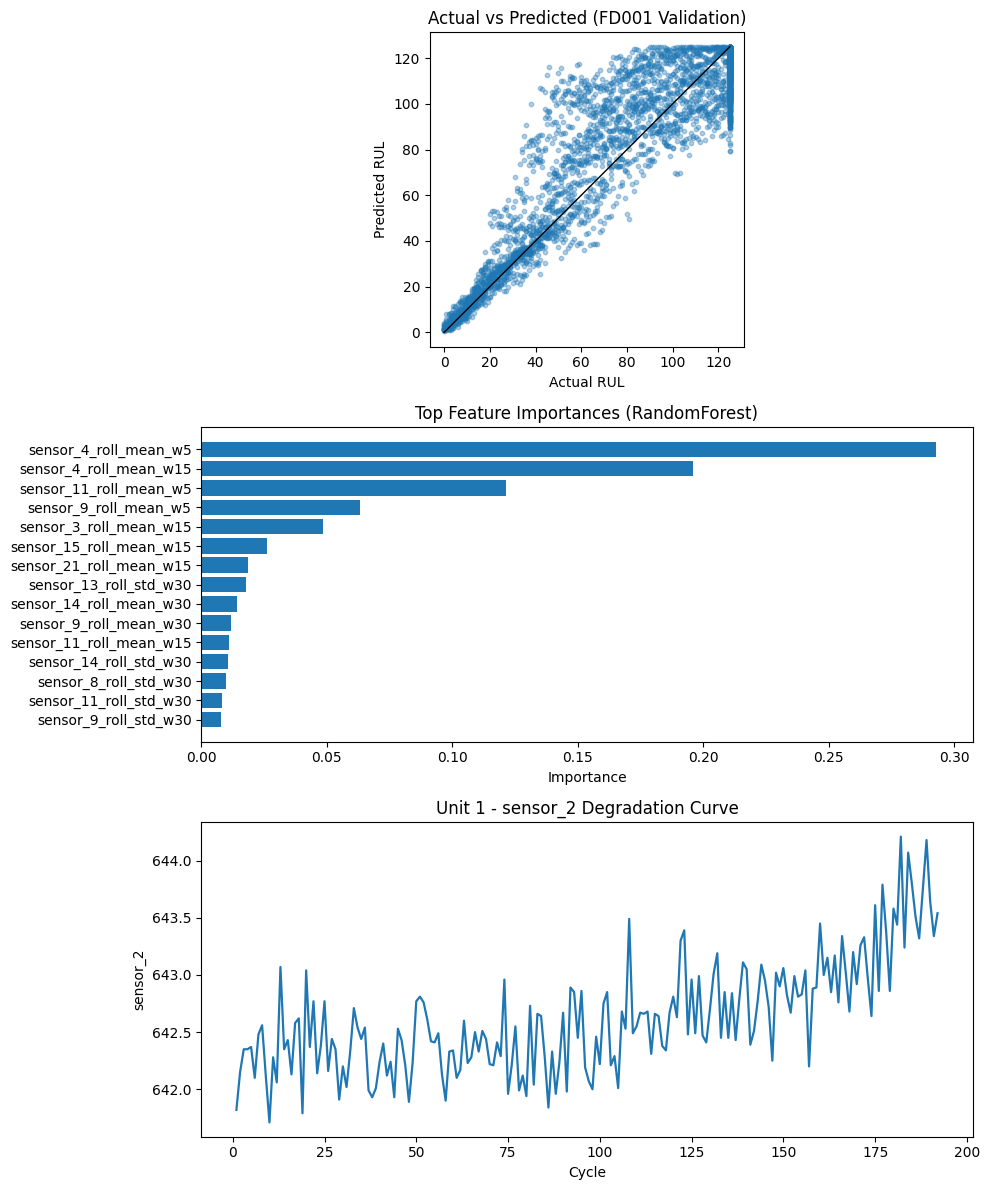

Saved: /Users/ayushkanyal/Desktop/Predictive Maintainence/reports/figures/diagnostic_plots_fd001.png


In [2]:
from pathlib import Path
import sys

import joblib
import matplotlib.pyplot as plt
import pandas as pd


def find_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "src").exists() and (candidate / "data").exists():
            return candidate
    raise FileNotFoundError("Could not locate project root containing src/ and data/.")


PROJECT_ROOT = find_project_root(Path.cwd().resolve())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.models import split_by_unit

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
MODELS_DIR = PROJECT_ROOT / "models"
OUTPUT_DIR = PROJECT_ROOT / "reports" / "figures"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

rolling_df = pd.read_parquet(PROCESSED_DIR / "train_FD001_rolling_features.parquet")
metadata_cols = {"unit_id", "cycle", "rul", "rul_raw"}
feature_cols = [col for col in rolling_df.columns if col not in metadata_cols]

train_df, val_df, _ = split_by_unit(rolling_df, validation_fraction=0.2, random_state=42)
model = joblib.load(MODELS_DIR / "fd001_random_forest_baseline.joblib")

y_true = val_df["rul"].to_numpy()
y_pred = model.predict(val_df[feature_cols])

importances = pd.Series(model.feature_importances_, index=feature_cols).sort_values(ascending=False)
top = importances.head(15).sort_values()

train_labeled = pd.read_parquet(PROCESSED_DIR / "train_FD001_with_rul_cap_125.parquet")
unit_id = int(train_labeled["unit_id"].iloc[0])
sensor = "sensor_2"
unit = train_labeled[train_labeled["unit_id"] == unit_id].sort_values("cycle")

fig, axes = plt.subplots(3, 1, figsize=(10, 12))

ax = axes[0]
ax.scatter(y_true, y_pred, s=10, alpha=0.35)
min_val = float(min(y_true.min(), y_pred.min()))
max_val = float(max(y_true.max(), y_pred.max()))
ax.plot([min_val, max_val], [min_val, max_val], color="black", lw=1)
ax.set_title("Actual vs Predicted (FD001 Validation)")
ax.set_xlabel("Actual RUL")
ax.set_ylabel("Predicted RUL")
ax.set_aspect("equal", "box")

ax = axes[1]
ax.barh(top.index, top.values)
ax.set_title("Top Feature Importances (RandomForest)")
ax.set_xlabel("Importance")

ax = axes[2]
ax.plot(unit["cycle"], unit[sensor], lw=1.6)
ax.set_title(f"Unit {unit_id} - {sensor} Degradation Curve")
ax.set_xlabel("Cycle")
ax.set_ylabel(sensor)

plt.tight_layout()
output_path = OUTPUT_DIR / "diagnostic_plots_fd001.png"
fig.savefig(output_path, dpi=200)
plt.show()

print("Saved:", output_path)